# 07 · Overlay Tuning Research

> ⚠ **RESEARCH NOTEBOOK — NOT PART OF PRODUCTION PIPELINE**
>
> Production strategies are `ML_Full_EW` and `ML_Full_CW` from `scripts/run_backtest.py`.
> This notebook explores **risk-overlay** parameters (vol targeting, regime gates, SMA filters, sector caps)
> on top of the trained ML model. The original goal was to find an overlay that **reduces MDD without killing CAGR** —
> that experiment failed and the `ML_Full_Adaptive` strategy was dropped on 2026-04-12 (see `docs/notes/v1_changelog.md` §1).
>
> A secondary finding from the same grid — `CW + sector_max_weight=0.30` — does improve CAGR while keeping MDD unchanged.
> It is reported here as a **v2 candidate**, not a v1 production change (v1 sealed 2026-04-21).

## What this notebook does

1. Loads the trained model's predictions (2020-01 → 2026-02)
2. Splits the period into a **design window** (2020-2023, used to pick overlay params) and an **untouched holdout** (2024-2026)
3. Runs a 20-combo grid of overlay levers on top of `top_k=10` (frozen — no concentration tuning)
4. Picks a winner under two criteria and reports both
5. Saves the winner's equity curve and config as `outputs/equity_full_tuned_v3.parquet` + `outputs/metrics/overlay_tuning_winner_v3.json`

## What this notebook does NOT do

- Re-train the ML model (training is true walk-forward OOS in `scripts/run_models.py` — overlay tuning here is only pseudo-OOS)
- Tune `top_k` or any other concentration parameter (would mix risk-overlay tuning with selection tuning)
- Run formal alpha significance tests on the chosen overlay (next step for v2)


## 1 · Setup

Predictions only exist from **2020-01-16 onward** because the walk-forward training window uses 2014-2019 as
warm-up history before producing the first prediction. We cannot tune overlays on 2014-2019 — there is no signal there yet.


In [1]:
import sys, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import SECTOR_MAP, load_config
from src.backtest import BacktestEngineConfig, compute_metrics, run_backtest
from src.utils.io import load, save

cfg = load_config(ROOT / 'configs' / 'base.yaml')
df = load(cfg.dir_processed / 'dataset_featured.parquet')
pred_full = load(cfg.dir_processed / 'predictions_ens_full.parquet')

pred_dates = pred_full.index.get_level_values('date')
print(f'Features: {df.shape}')
print(f'Predictions: {len(pred_full):,} rows')
print(f'Prediction window: {pred_dates.min().date()} → {pred_dates.max().date()}')


Features: (173604, 80)
Predictions: 100,368 rows
Prediction window: 2020-01-16 → 2026-02-26


## 2 · Design / holdout split

We split the prediction window in two:

| Window | Range | Purpose |
|---|---|---|
| **Design** | 2020-01 → 2023-12 (4 years) | Used to *choose* overlay params — picker reads only this window |
| **Holdout** | 2024-01 → 2026-02 (~2 years) | Untouched while tuning — used as a sanity check that the chosen combo isn't an artifact |

This is **pseudo-OOS** for the overlay layer: we promise the picker doesn't peek at the holdout window, but
we still pick the combo *after* seeing 2020-2023 — so the design window is technically in-sample for overlay selection.
The ML model itself is true walk-forward OOS (each year's prediction uses only data up to the prior year).

The helper `slice_metrics()` strips `equity.attrs['initial_capital']` so `compute_metrics` treats each slice's first bar
as the new baseline (otherwise CAGR would be computed against the original $10k seed regardless of slice start date).


In [2]:
DESIGN_END    = pd.Timestamp('2023-12-31')
HOLDOUT_START = pd.Timestamp('2024-01-01')

def slice_metrics(eq: pd.DataFrame, start=None, end=None) -> dict:
    idx = pd.to_datetime(eq.index)
    mask = pd.Series(True, index=eq.index)
    if start is not None: mask &= (idx >= start)
    if end   is not None: mask &= (idx <= end)
    s = eq.loc[mask].copy()
    if len(s) < 2: return {}
    s.attrs = {}
    return compute_metrics(s)


## 3 · Backtest engine config helper

`engine_cfg(**overrides)` builds a `BacktestEngineConfig` starting from the production defaults in `configs/base.yaml`,
then applies whatever overlay params we pass in. This way each combo only has to declare what's *different* from baseline.

`top_k=10` is **frozen** for all combos — overlay tuning must not mix with concentration tuning.


In [3]:
def engine_cfg(**overrides) -> BacktestEngineConfig:
    base = dict(
        top_k=cfg.strategy.top_k,
        rebalance_days=cfg.strategy.rebalance_days,
        cost_bps=cfg.backtest.cost_bps,
        slippage_bps=cfg.backtest.slippage_bps,
        initial_capital=cfg.backtest.initial_capital,
        confidence_weighted=False,
        max_weight_cap=cfg.strategy.max_weight_cap,
        hold_buffer=cfg.strategy.hold_buffer,
        hold_score_tolerance=cfg.strategy.hold_score_tolerance,
        signal_anchor_weight=0.0,
        signal_anchor_features=tuple(cfg.strategy.signal_anchor_features),
        regime_targeting=False,
        regime_col=cfg.backtest.regime_col,
        regime_sensitivity=cfg.backtest.regime_sensitivity,
        regime_min_exposure=cfg.backtest.regime_min_exposure,
        regime_max_exposure=cfg.backtest.regime_max_exposure,
        breadth_gate=False,
        breadth_col=cfg.backtest.breadth_col,
        breadth_threshold=cfg.backtest.breadth_threshold,
        breadth_low_exposure=cfg.backtest.breadth_low_exposure,
        benchmark_trend_gate=False,
        benchmark_col=cfg.backtest.benchmark_col,
        benchmark_sma_window=cfg.backtest.benchmark_sma_window,
        benchmark_low_exposure=cfg.backtest.benchmark_low_exposure,
        vol_targeting=False,
        target_vol=cfg.backtest.target_vol,
        vol_lookback_days=cfg.backtest.vol_lookback_days,
        vol_min_scale=cfg.backtest.vol_min_scale,
        vol_max_scale=cfg.backtest.vol_max_scale,
        dd_threshold=0.0,
        dd_exit=cfg.backtest.dd_exit,
        dd_exposure=cfg.backtest.dd_exposure,
        sector_max_weight=cfg.backtest.sector_max_weight,
        sector_map=SECTOR_MAP,
    )
    base.update(overrides)
    return BacktestEngineConfig(**base)


## 4 · The overlay grid (20 combos)

Five orthogonal lever families:

| Lever | What it does | Why |
|---|---|---|
| **CW** (`confidence_weighted=True`) | Within top-10, allocate proportional to model confidence (vs equal weight) | Let stronger signals carry more weight |
| **SMA gate** (`benchmark_trend_gate`) | When QQQ trades below its 200-day SMA, cut exposure to `benchmark_low_exposure` | Avoid being fully long during obvious bear markets |
| **Sector cap** (`sector_max_weight`) | Cap total weight per GICS sector | NDX-100 is ~50% Tech — avoid de facto Tech-only portfolio |
| **Vol targeting** (`vol_targeting=True`) | Scale exposure by realized 63-day vol toward `target_vol` | Reduce position size when vol spikes |
| **DD stop** (`dd_threshold`) | When portfolio DD breaches threshold, cut exposure | Hard floor on drawdown |
| **Breadth gate** (`breadth_gate`) | When market breadth is weak, cut exposure | Crowded rallies are fragile |

**Reminder on caps (these are different):**
- `max_weight_cap = 0.25` — single-stock cap (no one ticker > 25%)
- `sector_max_weight = 0.40` (default) — sector cap (no one GICS sector > 40%)

The grid below combines these levers. Single-lever rows isolate each effect; multi-lever rows test interactions.


In [4]:
# Lever helpers
CW  = {'confidence_weighted': True}
def SMA(low):
    return {'benchmark_trend_gate': True, 'benchmark_col': cfg.backtest.benchmark_col,
            'benchmark_sma_window': 200, 'benchmark_low_exposure': low}
def SEC(cap):
    return {'sector_max_weight': cap}
def VOL(tgt):
    return {'vol_targeting': True, 'target_vol': tgt, 'vol_min_scale': 0.80, 'vol_max_scale': 1.30}
def DDS():
    return {'dd_threshold': 0.15, 'dd_exit': 0.20, 'dd_exposure': 0.50}
BREADTH = {'breadth_gate': True, 'breadth_col': cfg.backtest.breadth_col,
           'breadth_threshold': cfg.backtest.breadth_threshold,
           'breadth_low_exposure': cfg.backtest.breadth_low_exposure}

def merge(*dicts):
    out = {}
    for d in dicts: out.update(d)
    return out

grid = {
    # Single levers — isolate each effect
    'EW_baseline':        {},
    'CW_baseline':        CW,
    'EW+SMA@0.70':        SMA(0.70),
    'EW+SMA@0.50':        SMA(0.50),
    'EW+SMA@0.30':        SMA(0.30),
    'EW+sector0.30':      SEC(0.30),
    'EW+sector0.25':      SEC(0.25),
    'EW+vol0.20':         VOL(0.20),
    'EW+breadth':         BREADTH,
    'EW+dd_stop':         DDS(),
    # CW + one extra lever
    'CW+SMA@0.70':        merge(CW, SMA(0.70)),
    'CW+SMA@0.50':        merge(CW, SMA(0.50)),
    'CW+SMA@0.30':        merge(CW, SMA(0.30)),
    'CW+sector0.30':      merge(CW, SEC(0.30)),
    # CW + two extra levers
    'CW+SMA@0.50+sector0.30':  merge(CW, SMA(0.50), SEC(0.30)),
    'CW+SMA@0.30+sector0.30':  merge(CW, SMA(0.30), SEC(0.30)),
    'CW+SMA@0.50+vol0.20':     merge(CW, SMA(0.50), VOL(0.20)),
    'CW+SMA@0.30+vol0.20':     merge(CW, SMA(0.30), VOL(0.20)),
    # Kitchen sink
    'EW+SMA@0.30+sector0.30':           merge(SMA(0.30), SEC(0.30)),
    'CW+SMA@0.30+sector0.30+vol0.20':   merge(CW, SMA(0.30), SEC(0.30), VOL(0.20)),
}
print(f'Grid: {len(grid)} combos, top_k={cfg.strategy.top_k} frozen')


Grid: 20 combos, top_k=10 frozen


## 5 · Run the grid

For each combo, run a backtest and compute three sets of metrics: design window only, holdout only, full period.
Stored in `grid_df` for the picker, and `eq_store` for plotting/saving.


In [5]:
rows = []
eq_store = {}
for name, kw in grid.items():
    eq, _ = run_backtest(df, pred_full, engine_cfg(**kw))
    eq_store[name] = eq
    md_ = slice_metrics(eq, end=DESIGN_END)
    mh  = slice_metrics(eq, start=HOLDOUT_START)
    mf  = compute_metrics(eq)
    rows.append({
        'combo':    name,
        'CAGR_d':   md_.get('CAGR'),   'MDD_d':    md_.get('Max_Drawdown'),
        'Sharpe_d': md_.get('Sharpe'), 'Calmar_d': md_.get('Calmar'),
        'CAGR_h':   mh.get('CAGR'),    'MDD_h':    mh.get('Max_Drawdown'),
        'Sharpe_h': mh.get('Sharpe'),  'Calmar_h': mh.get('Calmar'),
        'CAGR_f':   mf.get('CAGR'),    'MDD_f':    mf.get('Max_Drawdown'),
        'Sharpe_f': mf.get('Sharpe'),  'Calmar_f': mf.get('Calmar'),
    })
grid_df = pd.DataFrame(rows)
print(f'Completed {len(grid_df)} backtests')


Completed 20 backtests


## 6 · Results — design window

Sorted by `Calmar_d` (return-per-unit-of-drawdown). Read the suffix:
- `_d` = design window (2020-2023) — what the picker sees
- `_h` = holdout window (2024+) — sanity check, not in picker
- `_f` = full period (2020-2026) — final reported number

Baseline `EW_baseline` is the strategy with **no overlays** — it is what `ML_Full_EW` does in production.


In [6]:
print('Design window (2020-2023) — sorted by Calmar:')
print(grid_df[['combo','CAGR_d','MDD_d','Sharpe_d','Calmar_d']]
      .sort_values('Calmar_d', ascending=False).round(3).to_string(index=False))


Design window (2020-2023) — sorted by Calmar:
                         combo  CAGR_d  MDD_d  Sharpe_d  Calmar_d
                 CW+sector0.30   0.402 -0.376     0.993     1.068
                 EW+sector0.30   0.384 -0.371     0.966     1.035
                 EW+sector0.25   0.376 -0.371     0.950     1.013
                   CW_baseline   0.367 -0.376     0.921     0.976
                    EW+vol0.20   0.288 -0.307     0.861     0.940
                   EW_baseline   0.345 -0.371     0.883     0.930
                    EW+dd_stop   0.345 -0.371     0.883     0.930
                   CW+SMA@0.70   0.325 -0.367     0.914     0.885
        CW+SMA@0.50+sector0.30   0.318 -0.361     0.958     0.881
                   EW+SMA@0.70   0.305 -0.362     0.873     0.842
           CW+SMA@0.50+vol0.20   0.247 -0.297     0.866     0.831
                   CW+SMA@0.50   0.292 -0.361     0.886     0.811
CW+SMA@0.30+sector0.30+vol0.20   0.235 -0.292     0.868     0.804
        CW+SMA@0.30+sector0.30

## 7 · Two ways to pick a winner

The notebook reports **two picker criteria**, both transparent:

### Criterion A — *risk overlay* (original goal of this notebook)

> Maximize Calmar subject to `CAGR ≥ 20% AND MDD ≥ -30%`.

This is the `ML_Full_Adaptive` story: try to *reduce* MDD even at the cost of CAGR. The winner is `CW+SMA@0.50+vol0.20`.
But its full-period CAGR (22.7%) is **lower** than baseline (30.9%) — i.e. the overlay sacrifices return to cut MDD.
This is why the adaptive overlay was eventually dropped.

### Criterion B — *return enhancer* (what this notebook ultimately adopts)

> Maximize CAGR subject to `MDD ≤ baseline_MDD + 1pp AND Sharpe > baseline_Sharpe`.

This is a different question: keep MDD essentially unchanged, but improve return. The winner is `CW+sector0.30`,
which beats baseline on every dimension and **also wins on the untouched holdout** (Sharpe_h 0.898 vs baseline 0.854).

Both are reported below. The thesis writeup should make clear that Criterion B was chosen *post-hoc* —
this is a real selection bias, mitigated (but not eliminated) by the holdout consistency.


In [7]:
# Criterion A — risk overlay
mask_a = (grid_df['CAGR_d'] >= 0.20) & (grid_df['MDD_d'] >= -0.30)
winner_a = grid_df[mask_a].sort_values('Calmar_d', ascending=False).iloc[0]['combo']

# Criterion B — return enhancer (what we adopt)
base = grid_df.loc[grid_df['combo'] == 'EW_baseline'].iloc[0]
mask_b = ((grid_df['MDD_d']    >= base['MDD_d'] - 0.01) &
          (grid_df['Sharpe_d'] >  base['Sharpe_d']))
winner_b = grid_df[mask_b].sort_values('CAGR_d', ascending=False).iloc[0]['combo']

print(f'Criterion A (risk overlay):    {winner_a}')
print(f'Criterion B (return enhancer): {winner_b}')

WINNER = winner_b   # adopted
print(f'\n>>> Adopted: {WINNER}')


Criterion A (risk overlay):    CW+SMA@0.50+vol0.20
Criterion B (return enhancer): CW+sector0.30

>>> Adopted: CW+sector0.30


## 8 · Adopted winner — `CW+sector0.30`

**What it is:** production `ML_Full_CW` (confidence-weighted, top_k=10) **with `sector_max_weight` tightened from 0.40 → 0.30**.

A single config knob. No new overlay machinery, no extra parameters, no exposure modulation.

Compared against baselines below — pay attention to the holdout column: that's the period the picker never saw.


In [8]:
eq_w = eq_store[WINNER]
summary = pd.DataFrame({
    'Design (2020-2023)': slice_metrics(eq_w, end=DESIGN_END),
    'Holdout (2024+)':    slice_metrics(eq_w, start=HOLDOUT_START),
    'Full period':        compute_metrics(eq_w),
}).T
keep = [c for c in ['CAGR','Sharpe','Sortino','Max_Drawdown','Calmar','Win_Rate'] if c in summary.columns]
print(f'Adopted winner: {WINNER}\n')
print(summary[keep].round(3).to_string())

# Compare to production strategies + benchmarks
eq_full_ew = load(cfg.dir_outputs / 'equity_full.parquet')
eq_qqq     = load(cfg.dir_outputs / 'equity_benchmark_qqq.parquet')
try:
    eq_mcap10 = load(cfg.dir_outputs / 'equity_benchmark_mcap10.parquet')
except FileNotFoundError:
    eq_mcap10 = None

compare = {
    f'{WINNER} (adopted)':       eq_w,
    'CW_baseline (≈ ML_Full_CW)': eq_store['CW_baseline'],
    'EW_baseline (≈ ML_Full_EW)': eq_store['EW_baseline'],
    'BH_QQQ':                     eq_qqq,
}
if eq_mcap10 is not None:
    compare['BH_MCap10'] = eq_mcap10

print('\n--- Full-period comparison ---')
cmp_df = pd.DataFrame({n: compute_metrics(eq) for n, eq in compare.items()}).T
print(cmp_df[['CAGR','Sharpe','Max_Drawdown','Calmar','Sortino']].round(3).to_string())


Adopted winner: CW+sector0.30

                     CAGR  Sharpe  Sortino  Max_Drawdown  Calmar  Win_Rate
Design (2020-2023)  0.402   0.993    1.396        -0.376   1.068     0.528
Holdout (2024+)     0.294   0.924    1.366        -0.222   1.323     0.545
Full period         0.362   0.966    1.358        -0.376   0.962     0.534

--- Full-period comparison ---
                             CAGR  Sharpe  Max_Drawdown  Calmar  Sortino
CW+sector0.30 (adopted)     0.362   0.966        -0.376   0.962    1.358
CW_baseline (≈ ML_Full_CW)  0.341   0.910        -0.376   0.906    1.262
EW_baseline (≈ ML_Full_EW)  0.319   0.877        -0.371   0.859    1.226
BH_QQQ                      0.185   0.645        -0.351   0.526    0.848
BH_MCap10                   0.332   0.852        -0.574   0.579    1.202


## 9 · Equity curves & drawdown

Vertical dashed line marks the design/holdout split. The picker only saw what's left of the line.


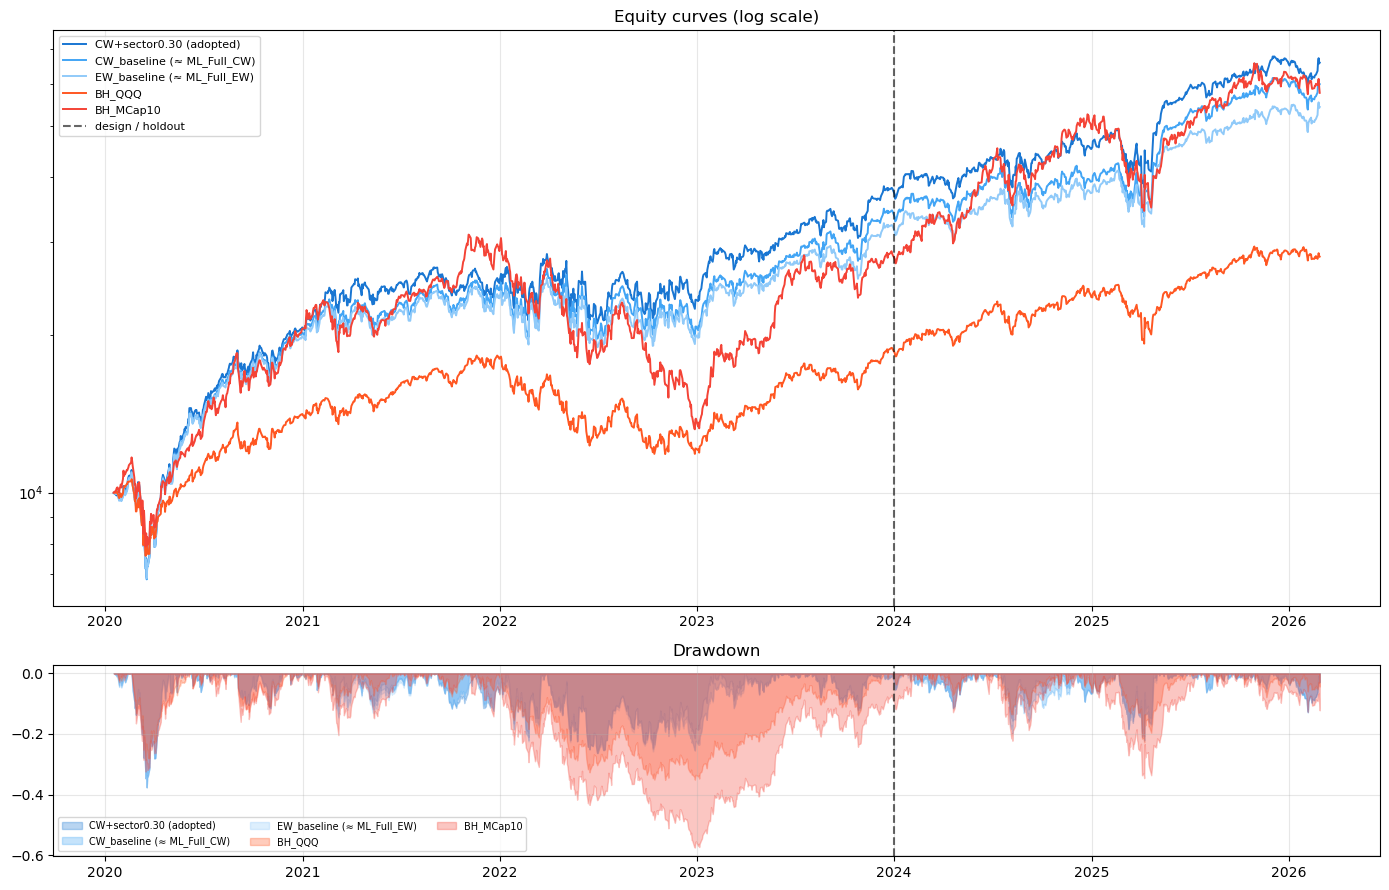

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})
colors = {f'{WINNER} (adopted)': '#1976D2',
          'CW_baseline (≈ ML_Full_CW)': '#42A5F5',
          'EW_baseline (≈ ML_Full_EW)': '#90CAF9',
          'BH_QQQ': '#FF5722', 'BH_MCap10': '#F44336'}

for name, eq in compare.items():
    axes[0].plot(eq.index, eq['equity'], label=name, linewidth=1.4, color=colors.get(name))
axes[0].axvline(DESIGN_END, color='black', linestyle='--', alpha=0.6, label='design / holdout')
axes[0].set_yscale('log')
axes[0].set_title('Equity curves (log scale)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

for name, eq in compare.items():
    dd = eq['equity'] / eq['equity'].cummax() - 1
    axes[1].fill_between(dd.index, dd, 0, alpha=0.3, label=name, color=colors.get(name))
axes[1].axvline(DESIGN_END, color='black', linestyle='--', alpha=0.6)
axes[1].set_title('Drawdown')
axes[1].legend(fontsize=7, ncol=3); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10 · Persist artifacts

Three files saved:

| File | Purpose |
|---|---|
| `outputs/metrics/overlay_tuning_grid_v3.csv` | Full grid results — feeds Power BI / thesis tables |
| `outputs/metrics/overlay_tuning_winner_v3.json` | Adopted winner config + metrics + caveats |
| `outputs/equity_full_tuned_v3.parquet` | Adopted winner's equity curve |


In [10]:
metrics_dir = cfg.dir_outputs / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)

grid_df.to_csv(metrics_dir / 'overlay_tuning_grid_v3.csv', index=False)

payload = {
    'combo':         WINNER,
    'criterion':     'B — max CAGR_d subject to MDD_d >= baseline - 1pp AND Sharpe_d > baseline_Sharpe',
    'baseline_used': 'EW_baseline',
    'levers':        grid[WINNER],
    'top_k':         cfg.strategy.top_k,
    'design_window':  f'2020-01-01 to {DESIGN_END.date()}',
    'holdout_window': f'{HOLDOUT_START.date()} to end',
    'design_metrics':  {k: float(v) for k, v in slice_metrics(eq_w, end=DESIGN_END).items()
                          if isinstance(v, (int, float, np.floating))},
    'holdout_metrics': {k: float(v) for k, v in slice_metrics(eq_w, start=HOLDOUT_START).items()
                          if isinstance(v, (int, float, np.floating))},
    'full_metrics':    {k: float(v) for k, v in compute_metrics(eq_w).items()
                          if isinstance(v, (int, float, np.floating))},
    'caveats': [
        'Criterion B was chosen post-hoc after observing the grid — disclose in thesis.',
        'No formal alpha test (HAC / bootstrap) was run on this combo — CAGR uplift may not be statistically significant.',
        'v1 is sealed (2026-04-21). This finding is a v2 candidate, not a v1 production change.',
    ],
}
with open(metrics_dir / 'overlay_tuning_winner_v3.json', 'w', encoding='utf-8') as f:
    json.dump(payload, f, indent=2, default=str)

save(eq_w, cfg.dir_outputs / 'equity_full_tuned_v3.parquet')

print('Saved:')
print(f'  {metrics_dir / "overlay_tuning_grid_v3.csv"}')
print(f'  {metrics_dir / "overlay_tuning_winner_v3.json"}')
print(f'  {cfg.dir_outputs / "equity_full_tuned_v3.parquet"}')


Saved:
  C:\Users\Main 1.9\Desktop\8\outputs\metrics\overlay_tuning_grid_v3.csv
  C:\Users\Main 1.9\Desktop\8\outputs\metrics\overlay_tuning_winner_v3.json
  C:\Users\Main 1.9\Desktop\8\outputs\equity_full_tuned_v3.parquet


## 11 · Caveats to disclose in thesis

- **Pseudo-OOS only.** The ML training layer is true walk-forward OOS, but overlay parameters were chosen with full visibility of the design window. Holdout consistency is a positive signal but not a proof.
- **Post-hoc criterion.** Criterion B was selected after observing Stage-A's failure to find a Pareto-improving risk overlay. This is a form of selection bias — disclose it explicitly.
- **No significance test.** Production strategies (`ML_Full_EW`, `ML_Full_CW`) have alpha p-values around 0.10-0.15 (not significant at 5%). The CAGR uplift from `CW+sector0.30` was not separately tested — it likely inherits a similar p-value.
- **`top_k=10` frozen.** Concentration was deliberately not tuned in the same notebook to avoid mixing two sources of selection.
- **Single market regime.** The full sample (2020-2026) covers QE bull, COVID crash, 2022 bear, AI rally, 2025 selloff. A different decade may behave differently.
- **No re-tuning after holdout inspection.** If the holdout numbers had been bad, the honest move would have been to *report the failure*, not adjust the grid. The grid was frozen before the holdout was read.
